# Lab1. 线性回归


1. 读取数据
2. 可视化
3. 计算损失函数
4. 解析法求解最优解
5. 梯度下降
6. 等高线代价函数


# 1.单变量线性回归


## 1.1 读取数据


In [859]:
import numpy as np
import matplotlib.pyplot as plt

In [860]:
ex1data1 = "./ex1data1.txt"
data1 = np.loadtxt(ex1data1, delimiter=",")
print(data1.shape, data1.ndim)

(97, 2) 2


## 1.2 可视化数据


(97,) 1


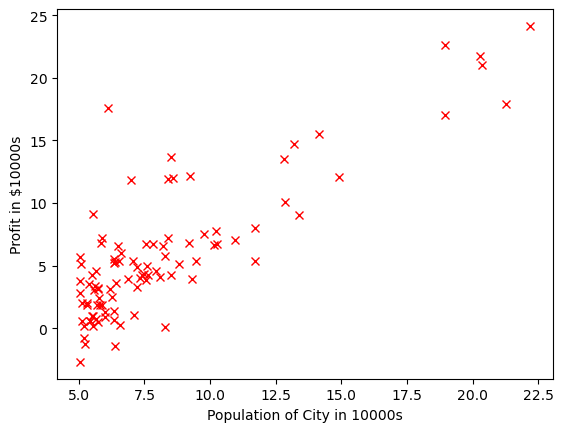

In [861]:
x = data1[:, 0]
y = data1[:, 1]
print(x.shape, x.ndim)

# 使用plt.xlabel plt.ylabel plt.plot函数来进行数据可视化
plt.xlabel("Population of City in 10000s")
plt.ylabel("Profit in $10000s")
plt.plot(x, y, "xr")

## 1.3 训练线性回归模型

### 1.3.1 数据预处理


In [862]:
# 使用m存放数据点的个数
m = data1.shape[0]

# 使用np.ones创建名为x0的二维数组，规模为m*1
x0 = np.ones((m, 1))

# 使用x1存放读入数据第一列“人口数量”，存为列向量
x1 = data1[:, [0]]

# 使用np.hstack函数将x0和x1进行合并存放于x,打印x
X = np.hstack((x0, x1)).T
print(X)

# 使用y存放读入数据第二列“收益”，存为列向量
y = data1[:, [1]].T

# 使用np.zeros初始化theta,规模为2*1,打印theta
theta = np.zeros((2, 1))

[[ 1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.      1.      1.
   1.      1.      1.      1.      1.      1.      1.    ]
 [ 6.1101  5.5277  8.5186  7.0032  5.8598  8.3829  7.4764  8.5781  6.4862
   5.0546  5.7107 14.164   5.734   8.4084  5.6407  5.3794  6.3654  5.1301
   6.4296  7.0708  6.1891 20.27    5.4901  6.3261  5.5649 18.945  12.828
  10.957  13.176  22

### 1.3.2 代价函数


In [863]:
# 利用numpy中的函数编写代价函数
# 注意避免编写一个完整的长公式，分步计算便于调试
# 注意数组维度
def computeCost(X, y, w):
    m = y.shape[1]
    L = 0
    diff = w.T @ X - y
    L = diff @ diff.T / (2 * m)
    return L[0][0]


print(computeCost(X, y, theta))

32.07273387745567


### 1.3.3 用于单变量线性回归的梯度下降法算法


In [864]:
# 定义学习率alpha
# 迭代次数iteration
# 使用cost存放每次迭代后计算出的代价函数的取值
# 进行梯度下降
def gradientDescent(X, y, w, alpha, num_iters):
    m = X.shape[1]
    cost_history = np.zeros(num_iters)
    for i in range(num_iters):

        diff = w.T @ X - y
        w = w - X @ (diff.T) * alpha / m

        cost_history[i] = computeCost(X, y, w)

    return w, cost_history


alpha = 0.01  # alpha是学习率
num_iters = 1500  # 迭代次数
w, cost_history = gradientDescent(X, y, theta, alpha, num_iters)
print(w)

[[-3.63029144]
 [ 1.16636235]]


### 1.3.4 通过求导法直接计算最优解


In [865]:
xxt = np.dot(X, X.T)
xyt = np.dot(X, y.T)
xxt_inv = np.linalg.inv(xxt)

theta_mat = np.matmul(np.linalg.inv(np.matmul(X, X.T)), np.matmul(X, y.T))
print(theta_mat)

[[-3.89578088]
 [ 1.19303364]]


## 1.4 使用训练得到的模型进行预测并可视化结果


In [866]:
# 使用训练的带的参数，代入x0=5.0求得对应的y0
x0 = 5.0
y01 = w[0] + w[1] * x0
y02 = theta_mat[0] + theta_mat[1] * x0

# 使用训练的带的参数，代入x1=25.0求得对应的y1
x1 = 25.0
y11 = w[0] + w[1] * x1
y12 = theta_mat[0] + theta_mat[1] * x1

print(y01, y11)
print(y02, y12)

[2.20152031] [25.52876732]
[2.06938734] [25.93006023]


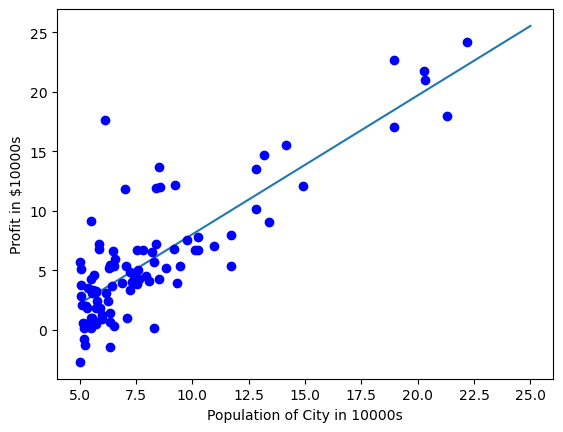

In [867]:
# 利用plt.xlabel plt.ylabel设定坐标轴名称
# 利用plt.plot画出拟合的直线，可利用上一步计算得到的两个坐标点plt.plot((x0, x1), (y0, y1))
# 利用plt.plot画出原始数据散点图
plt.xlabel("Population of City in 10000s")
plt.ylabel("Profit in $10000s")
plt.plot((x0, x1), (y01, y11))
plt.plot(data1[:, 0], data1[:, 1], "ob")

## 1.5 可视化线性回归的代价函数


Visualizing L(w_0, w_1) ...


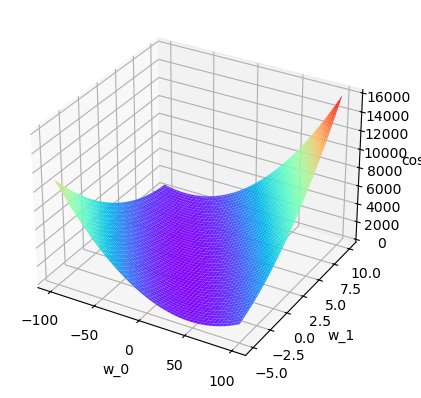

In [868]:
print("Visualizing L(w_0, w_1) ...")
w0_vals = np.linspace(-100, 100, 100)
w1_vals = np.linspace(-5, 10, 100)
cost_vals = np.zeros((len(w0_vals), len(w1_vals)))
for i in range(len(w0_vals)):
    for j in range(len(w1_vals)):
        cost_vals[i, j] = computeCost(X, y, np.array([[w0_vals[i]], [w1_vals[j]]]))
cost_vals = cost_vals.T

w0_vals_m, w1_vals_m = np.meshgrid(w0_vals, w1_vals)

fig = plt.figure()
ax = plt.axes(projection="3d")
ax.plot_surface(w0_vals_m, w1_vals_m, cost_vals, cmap="rainbow")
ax.set_xlabel("w_0")
ax.set_ylabel("w_1")
ax.set_zlabel("cost")
plt.show()

## 1.6 绘制等高线代价函数


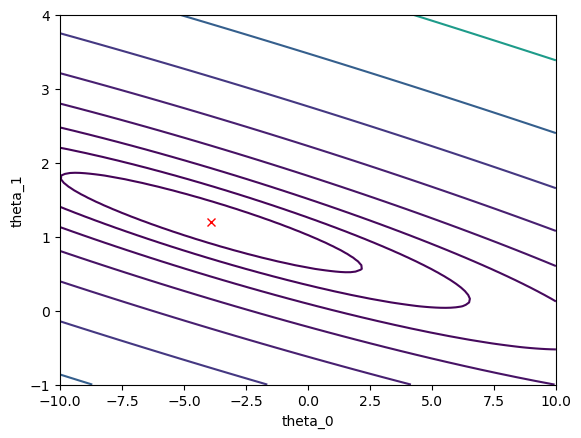

In [869]:
theta0_val = np.linspace(-10, 10, 100)
theta1_val = np.linspace(-1, 4, 100)
cost_val = np.zeros((len(theta0_val), len(theta1_val)))
for i in range(len(theta0_val)):
    for j in range(len(theta1_val)):
        theta_val = np.array([[theta0_val[i]], [theta1_val[j]]])
        cost_val[i, j] = computeCost(X, y, theta_val)

cost_val = cost_val.T

plt.contour(theta0_val, theta1_val, cost_val, np.logspace(-2, 3, 20))
plt.xlabel("theta_0")
plt.ylabel("theta_1")
plt.plot(theta_mat[0], theta_mat[1], "rx")
plt.show()

# 2.多变量线性回归


## 2.0 读取数据


In [870]:
data = np.loadtxt("./ex1data2.txt", delimiter=",")

# 使用m存放数据点的个数
m = data.shape[0]

# 使用x存放读入数据，取[0，2）这个区间的列，不包括2，存为列向量
X = data[:, :2].T

# 使用y存放读入数据，存为列向量
y = data[:, [2]].T

# 使用np.zeros初始化theta,规模为2*1,打印theta
theta = np.zeros([2, 1])
print(theta)

# 可以输出前10行数据，查看数据内容
for i in range(10):
    print(f"X = ( {X[0][i]} , {X[1][i]} ) , y = {y[0][i]}")

[[0.]
 [0.]]
X = ( 2104.0 , 3.0 ) , y = 399900.0
X = ( 1600.0 , 3.0 ) , y = 329900.0
X = ( 2400.0 , 3.0 ) , y = 369000.0
X = ( 1416.0 , 2.0 ) , y = 232000.0
X = ( 3000.0 , 4.0 ) , y = 539900.0
X = ( 1985.0 , 4.0 ) , y = 299900.0
X = ( 1534.0 , 3.0 ) , y = 314900.0
X = ( 1427.0 , 3.0 ) , y = 198999.0
X = ( 1380.0 , 3.0 ) , y = 212000.0
X = ( 1494.0 , 3.0 ) , y = 242500.0


## 2.1 特征规范化


In [871]:
# 特征规范化
# 计算mu、sigma
# 返回规范化后的结果
def featureNormalize(X):
    mu = np.mean(X, axis=1).reshape(2, 1)
    sigma = np.std(X, axis=1, ddof=1).reshape(2, 1)
    return (X - mu) / sigma, mu, sigma

## 2.2 使用向量法实现多变量的梯度下降法


### 2.2.1 向量化代价函数


In [872]:
# 根据这个向量化的代价函数(请看实验说明书)，升级原先的computeCost()到computeCostMulti()函数
def computeCostMulti(X, y, theta):
    L = 0
    diff = theta.T @ X - y
    L = diff @ diff.T / (2 * m)
    return L[0][0]


print(computeCostMulti(X, y, theta))

65591548106.45744


### 2.2.2 向量化多变量梯度下降法


In [873]:
# 根据向量化的梯度(请看实验说明书)，升级gradientDescent()到gradientDescentMulti()函数。
# 定义学习率alpha
# 迭代次数iteration
# 使用cost存放每次迭代后计算出的代价函数的取值
# 进行梯度下降
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    cost_history = np.zeros(num_iters)
    for i in range(num_iters):

        diff = theta.T @ X - y
        theta = theta - X @ (diff.T) * alpha / m

        cost_history[i] = computeCost(X, y, theta)

    return theta, cost_history

### 2.2.3 房价预测(先对输入数据进行规范化)


In [874]:
# 先规范化数据
# 使用vstack，拓展规范化后的数据
# 可以打印出数据查看数据内容
X, mu, sigma = featureNormalize(X)
x0 = np.ones([1, m])
X = np.vstack((x0, X))
print(mu)
print(sigma)
print(X.shape)
for i in range(10):
    print(f"X = ( {X[0,i]} , {X[1,i]} , {X[2,i]} ) , y = {y[0,i]}")
y = (data[:, 2][:, np.newaxis]).T

[[2000.68085106]
 [   3.17021277]]
[[7.94702354e+02]
 [7.60981887e-01]]
(3, 47)
X = ( 1.0 , 0.13000986907454054 , -0.2236751871685913 ) , y = 399900.0
X = ( 1.0 , -0.5041898382231769 , -0.2236751871685913 ) , y = 329900.0
X = ( 1.0 , 0.502476363836692 , -0.2236751871685913 ) , y = 369000.0
X = ( 1.0 , -0.7357230646969468 , -1.5377669117840669 ) , y = 232000.0
X = ( 1.0 , 1.2574760153815938 , 1.0904165374468842 ) , y = 539900.0
X = ( 1.0 , -0.019731728481864972 , 1.0904165374468842 ) , y = 299900.0
X = ( 1.0 , -0.5872397998931161 , -0.2236751871685913 ) , y = 314900.0
X = ( 1.0 , -0.7218814044186236 , -0.2236751871685913 ) , y = 198999.0
X = ( 1.0 , -0.7810230437896409 , -0.2236751871685913 ) , y = 212000.0
X = ( 1.0 , -0.6375731099961096 , -0.2236751871685913 ) , y = 242500.0


### 2.2.4 通过学习曲线（Learning Curve）选择合适的学习率（Learning Rate）


65591548106.45744
cost= [6.43007496e+10 6.30367950e+10 6.17991118e+10 ... 2.04328364e+09
 2.04328361e+09 2.04328358e+09]
[[340412.56301439]
 [110540.56654627]
 [ -6558.99054811]]


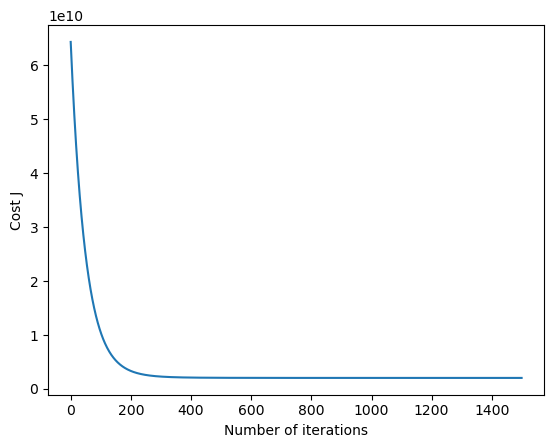

In [875]:
theta = np.zeros((X.shape[0], 1))
print(computeCostMulti(X, y, theta))
theta_star, J_hist = gradientDescentMulti(X, y, theta, 0.01, 1500)
print("cost=", J_hist)
print(theta_star)
# 绘制学习曲线
plt.xlabel("Number of iterations")
plt.ylabel("Cost J")
plt.plot(np.arange(1500), J_hist)

## 2.3 使用解析法最小化代价函数


In [876]:
# 编写公式直接求取theta最优解
theta_mat = np.linalg.inv(X @ (X.T)) @ (X @ (y.T))
print(theta_mat)

[[340412.65957447]
 [110631.05027885]
 [ -6649.47427082]]


## 2.4 使用训练得到的模型进行预测


In [877]:
# 使用训练得到的模型进行预测
# 注意，输入的数据需要规范化
x_test = np.array([[1650], [3]])
x_test = (x_test - mu) / sigma
x_test = np.vstack((np.array([[1]]), x_test))
print(x_test)
y_test1 = theta_star.T @ x_test
y_test2 = theta_mat.T @ x_test
print(y_test1)
print(y_test2)
# [293081.4643349]

[[ 1.        ]
 [-0.4412732 ]
 [-0.22367519]]
[[293101.05685748]]
[[293081.4643349]]
